# ORIENT'IA — Pipeline Machine Learning de recommandation de parcours

**Objectif.** Entraîner et évaluer un modèle de classification multi-classe (+ recommandation Top-K)
qui, à partir du profil déclaré d'un candidat (bac, matières, goûts, activités, préférences
pédagogiques...), recommande les parcours de formation de l'ISPM les plus adaptés.

**Principe méthodologique central (imposé par le sujet) :**

- Le modèle est **entraîné uniquement sur les données synthétiques** (`donnees_synthetiques_modifiees.csv`, 1000 lignes).
- Les **36 réponses réelles** (`Réponse enquête - Réponses au formulaire 1.csv`) ne sont **jamais mélangées** à l'entraînement :
  elles servent exclusivement de **test externe** pour mesurer la généralisation synthétique → réel.
- Les personnes n'ayant jamais étudié à l'ISPM n'ont pas de filière connue : elles sont conservées
  (jamais supprimées) mais séparées en `test_real_unlabeled` (pas de vérité terrain) et
  `test_real_labeled` (filière connue, utilisable pour les métriques supervisées).

**Reproductibilité.** `random_state = 42` partout. Les artefacts (modèle, préprocesseur, métadonnées)
sont sauvegardés dans `../models/`.

**Honnêteté scientifique.** Ce notebook ne masque aucune limite : le dataset réel est petit (n=36,
20 labellisés), certains intitulés de questions diffèrent fortement entre les deux enquêtes, et les
résultats doivent être lus avec cette prudence en tête (cf. section finale « Limites »).


## 0. Imports & configuration

In [1]:

import re
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")
for d in (PROCESSED_DIR, MODELS_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Configuration OK — random_state =", RANDOM_STATE)


Configuration OK — random_state = 42


## 1. Chargement des données

Les deux fichiers CSV bruts sont chargés tels quels. Aucune modification n'est faite sur les fichiers
sources : tout le traitement se fait en mémoire, sur des copies.

In [2]:

SYNTH_PATH = DATA_DIR / "donnees_synthetiques_modifiees.csv"
REAL_PATH = DATA_DIR / "Réponse_enquête_-_Réponses_au_formulaire_1.csv"

synth = pd.read_csv(SYNTH_PATH)
real = pd.read_csv(REAL_PATH)

print(f"Dataset synthétique : {synth.shape[0]} lignes x {synth.shape[1]} colonnes")
print(f"Dataset réel        : {real.shape[0]} lignes x {real.shape[1]} colonnes")


Dataset synthétique : 1000 lignes x 19 colonnes
Dataset réel        : 36 lignes x 19 colonnes


## 2. Harmonisation des schémas (`schema_mapping`)

Les deux fichiers contiennent les **19 mêmes questions dans le même ordre**, mais certains intitulés
diffèrent légèrement (précisions entre parenthèses, espace final...). On construit un mapping
**position → position** (vérifié colonne par colonne) puis on adopte les libellés du dataset
synthétique comme référence unique pour la suite du pipeline.

In [3]:

assert synth.shape[1] == real.shape[1] == 19, "Le nombre de colonnes diffère entre les deux fichiers !"

SCHEMA_MAPPING = dict(zip(real.columns, synth.columns))

print("Mapping des colonnes (réel -> synthétique) :\n")
for c_real, c_synth in SCHEMA_MAPPING.items():
    marker = "   " if c_real == c_synth else " * "
    print(f"{marker}{c_real!r}\n     -> {c_synth!r}")

real = real.rename(columns=SCHEMA_MAPPING)
assert list(synth.columns) == list(real.columns)
print("\nSchémas harmonisés avec succès (colonnes identiques dans les deux datasets).")


Mapping des colonnes (réel -> synthétique) :

   'Horodateur'
     -> 'Horodateur'
   'Vous êtes actuellement :'
     -> 'Vous êtes actuellement :'
   'Quelle était votre série au Baccalauréat ?'
     -> 'Quelle était votre série au Baccalauréat ?'
   'Quelles étaient vos matières préférées au lycée ?'
     -> 'Quelles étaient vos matières préférées au lycée ?'
   'Dans quelles matières vous étiez doués?'
     -> 'Dans quelles matières vous étiez doués?'
   "Dans quelles activités pensez-vous être naturellement à l'aise ?"
     -> "Dans quelles activités pensez-vous être naturellement à l'aise ?"
   'Parmi les activités suivantes, lesquelles vous attirent le plus ?'
     -> 'Parmi les activités suivantes, lesquelles vous attirent le plus ?'
   'Quel type de problème aimez-vous le plus résoudre ?'
     -> 'Quel type de problème aimez-vous le plus résoudre ?'
   "Quel type d'activité pédagogique vous attire le plus ?"
     -> "Quel type d'activité pédagogique vous attire le plus ?"
   'A

## 3. Analyse exploratoire (EDA) — dataset synthétique (1000 obs.)

In [4]:

print("Valeurs manquantes (synthétique) :")
display(synth.isna().sum().to_frame("n_missing"))

print("\nDoublons exacts :", synth.duplicated().sum())


Valeurs manquantes (synthétique) :


,n_missing
Horodateur,0
Vous êtes actuellement :,0
Quelle était votre série au Baccalauréat ?,0
Quelles étaient vos matières préférées au lycée ?,0
Dans quelles matières vous étiez doués?,0
Dans quelles activités pensez-vous être naturellement à l'aise ?,0
"Parmi les activités suivantes, lesquelles vous attirent le plus ?",0
Quel type de problème aimez-vous le plus résoudre ?,0
Quel type d'activité pédagogique vous attire le plus ?,0
Aimez-vous plutôt la pratique ou les leçons (théorie) ?,0



Doublons exacts : 0


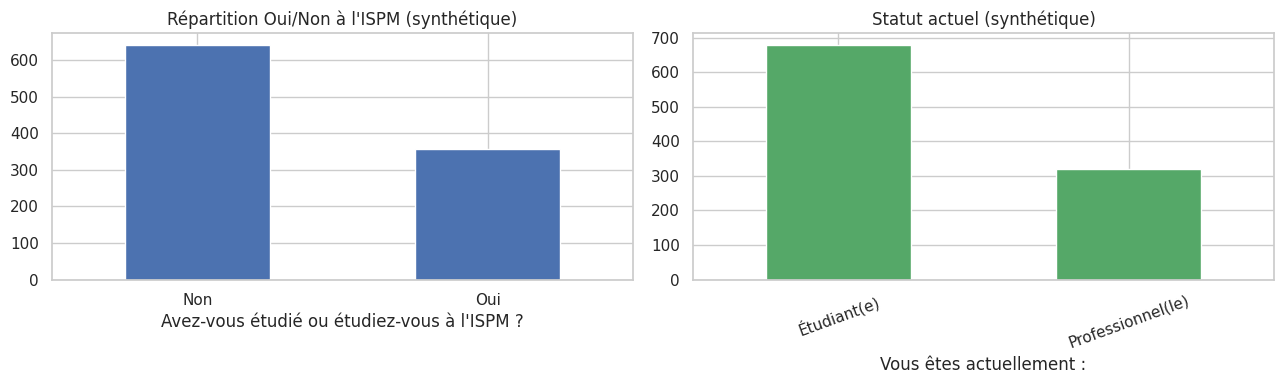

In [5]:

COL_ISPM = "Avez-vous étudié ou étudiez-vous à l'ISPM ?"
COL_FILIERE = "Si oui, quelle est / a été votre filière (mention) à l'ISPM ?"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
synth[COL_ISPM].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Répartition Oui/Non à l'ISPM (synthétique)")
axes[0].tick_params(axis='x', rotation=0)

synth["Vous êtes actuellement :"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Statut actuel (synthétique)")
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


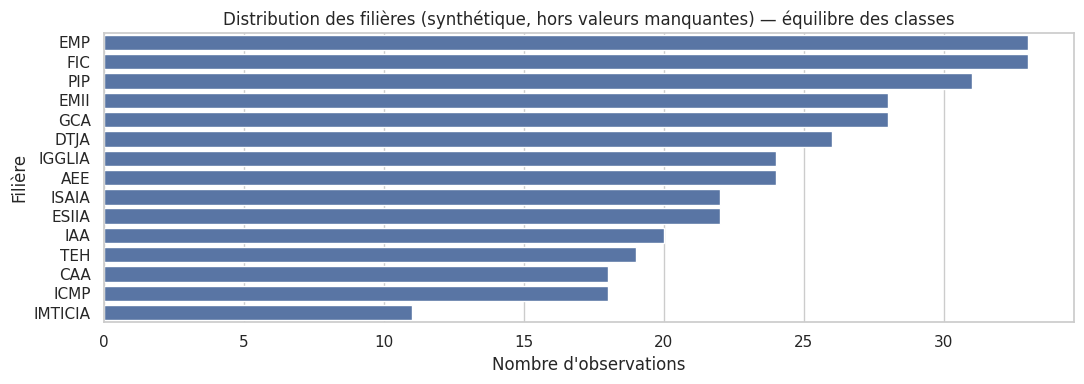

filiere_code
EMP        33
FIC        33
PIP        31
EMII       28
GCA        28
DTJA       26
IGGLIA     24
AEE        24
ISAIA      22
ESIIA      22
IAA        20
TEH        19
CAA        18
ICMP       18
IMTICIA    11
Name: count, dtype: int64

643 lignes sans filière (candidats n'ayant pas étudié à l'ISPM) — conservées, non supprimées.


In [6]:

# normalize_filiere : extrait le code de filière ('IGGLIA') a partir du libelle complet
# ('IGGLIA : Informatique de Gestion...'). Renvoie NaN si valeur manquante.
def normalize_filiere(value):
    if pd.isna(value):
        return np.nan
    code_ = str(value).split(":")[0].strip()
    return code_ if code_ else np.nan

synth["filiere_code"] = synth[COL_FILIERE].apply(normalize_filiere)

plt.figure(figsize=(11, 4))
order = synth["filiere_code"].value_counts().index
sns.countplot(y=synth["filiere_code"], order=order, color="#4C72B0")
plt.title("Distribution des filières (synthétique, hors valeurs manquantes) — équilibre des classes")
plt.xlabel("Nombre d'observations")
plt.ylabel("Filière")
plt.tight_layout()
plt.show()

print(synth["filiere_code"].value_counts())
print(f"\n{synth['filiere_code'].isna().sum()} lignes sans filière (candidats n'ayant pas étudié à l'ISPM) — conservées, non supprimées.")


**Constat EDA synthétique :**
- Pas de doublons exacts, pas de valeurs manquantes sur les colonnes de features.
- 643/1000 lignes n'ont pas de filière (candidats "Non" à l'ISPM) : c'est **normal et attendu**, ces
  lignes n'ont simplement pas de vérité terrain de filière, elles ne sont pas des erreurs.
- Les 357 lignes labellisées sont réparties sur **15 classes**, avec un déséquilibre modéré
  (11 à 33 observations par classe, ratio max/min ≈ 3). Ce déséquilibre justifie l'usage de
  `class_weight="balanced"` pour les modèles retenus.

## 4. EDA du dataset réel (36 réponses) + comparaison au synthétique

Le sujet demande explicitement de détecter un éventuel **distribution shift**. On regarde d'abord
les valeurs manquantes et la distribution du statut ISPM/filière, puis (section 7) le vocabulaire
des réponses ouvertes à choix multiples, qui est le point de divergence le plus important.

Valeurs manquantes (réel) :


,n_missing
Horodateur,0
Vous êtes actuellement :,0
Quelle était votre série au Baccalauréat ?,0
Quelles étaient vos matières préférées au lycée ?,2
Dans quelles matières vous étiez doués?,2
Dans quelles activités pensez-vous être naturellement à l'aise ?,2
"Parmi les activités suivantes, lesquelles vous attirent le plus ?",2
Quel type de problème aimez-vous le plus résoudre ?,2
Quel type d'activité pédagogique vous attire le plus ?,2
Aimez-vous plutôt la pratique ou les leçons (théorie) ?,1


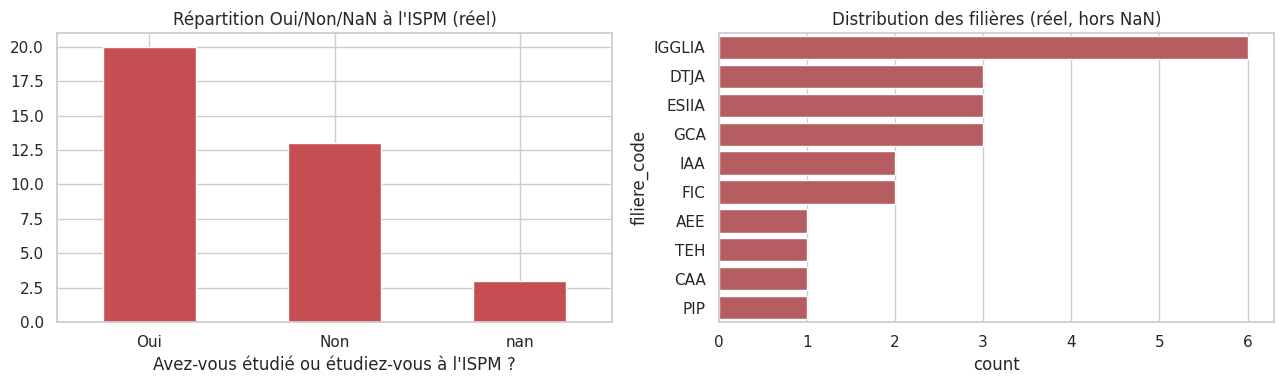


Statut ISPM (réel), avant nettoyage :
Avez-vous étudié ou étudiez-vous à l'ISPM ?
Oui    20
Non    13
NaN     3
Name: count, dtype: int64

3 lignes ont un statut ISPM lui-même manquant (ni Oui ni Non déclaré) : traitées comme non-labellisées ci-après.


In [7]:

real["filiere_code"] = real[COL_FILIERE].apply(normalize_filiere)

print("Valeurs manquantes (réel) :")
display(real.isna().sum().to_frame("n_missing"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
real[COL_ISPM].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Répartition Oui/Non/NaN à l'ISPM (réel)")
axes[0].tick_params(axis='x', rotation=0)

order_real = real["filiere_code"].value_counts().index
sns.countplot(y=real["filiere_code"], order=order_real, color="#C44E52", ax=axes[1])
axes[1].set_title("Distribution des filières (réel, hors NaN)")
plt.tight_layout()
plt.show()

print("\nStatut ISPM (réel), avant nettoyage :")
print(real[COL_ISPM].value_counts(dropna=False))
print("\n3 lignes ont un statut ISPM lui-même manquant (ni Oui ni Non déclaré) : traitées comme non-labellisées ci-après.")


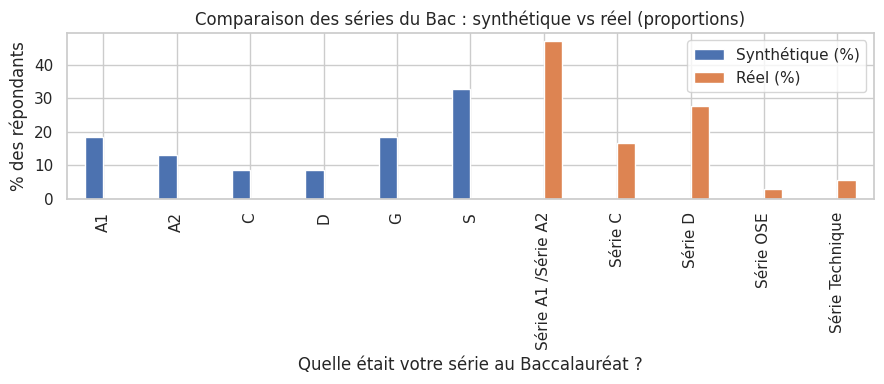

,Synthétique (%),Réel (%)
Quelle était votre série au Baccalauréat ?,,
A1,18.6,0.0
A2,13.0,0.0
C,8.7,0.0
D,8.5,0.0
G,18.4,0.0
S,32.8,0.0
Série A1 /Série A2,0.0,47.2
Série C,0.0,16.7
Série D,0.0,27.8


In [8]:

# Comparaison directe synthétique vs réel sur une variable structurante : la série du Bac
fig, ax = plt.subplots(figsize=(9, 4))
synth_bac = synth["Quelle était votre série au Baccalauréat ?"].value_counts(normalize=True)
real_bac = real["Quelle était votre série au Baccalauréat ?"].value_counts(normalize=True)
comp = pd.DataFrame({"Synthétique (%)": synth_bac * 100, "Réel (%)": real_bac * 100}).fillna(0)
comp.plot(kind="bar", ax=ax)
plt.title("Comparaison des séries du Bac : synthétique vs réel (proportions)")
plt.ylabel("% des répondants")
plt.tight_layout()
plt.show()
display(comp.round(1))


**Constat :** les libellés de série de Bac diffèrent en surface (`'S'` vs `'Série S'`,
`'A1 /A2'` combiné dans le réel) et le réel introduit des séries absentes du synthétique
(`Série OSE`, `Série Technique`). C'est un premier indice de shift qui sera quantifié plus
précisément section 7 (vocabulaire hors-vocab).

## 5. Nettoyage : suppression de la colonne métier, exclusion de l'horodateur

- La colonne **métier actuel** est supprimée des deux datasets (beaucoup de valeurs manquantes,
  non nécessaire pour recommander un parcours à partir du profil déclaré, cf. section 5 du sujet).
- La colonne **Horodateur** est conservée pour la traçabilité mais **exclue de X** (pas de valeur
  pédagogique, risque de biais artificiel).
- La colonne **satisfaction formation/métier** n'est pas dans la liste des features du sujet
  (section 10) : elle est également exclue de X (elle ne concerne de toute façon que les diplômés).

In [9]:

COL_METIER = "Si vous êtes diplômé(e) / professionnel(le), quel est votre métier actuel ?"
COL_HORODATEUR = "Horodateur"
COL_SATISFACTION = ("Si vous êtes diplômés, avec le recul, quel est votre niveau de "
                     "satisfaction concernant l'adéquation entre votre formation et votre métier ?")

synth = synth.drop(columns=[COL_METIER])
real = real.drop(columns=[COL_METIER])

print(f"Après suppression de la colonne métier : synthétique={synth.shape}, réel={real.shape}  (attendu : 18 colonnes + 1 colonne 'filiere_code' déjà ajoutée)")

FEATURE_COLUMNS = [
    "Vous êtes actuellement :",
    "Quelle était votre série au Baccalauréat ?",
    "Quelles étaient vos matières préférées au lycée ?",
    "Dans quelles matières vous étiez doués?",
    "Dans quelles activités pensez-vous être naturellement à l'aise ?",
    "Parmi les activités suivantes, lesquelles vous attirent le plus ?",
    "Quel type de problème aimez-vous le plus résoudre ?",
    "Quel type d'activité pédagogique vous attire le plus ?",
    "Aimez-vous plutôt la pratique ou les leçons (théorie) ?",
    "Quel rythme de travail vous correspond le mieux ?",
    "Dans quel environnement aimeriez-vous travailler ?",
    "Quels sont vos domaines d'intérêt principaux ?",
    "Préférez-vous travailler principalement",
    "Qu'est-ce qui est le plus important pour vous dans le choix d'une formation ?",
]
assert set(FEATURE_COLUMNS).issubset(synth.columns)
print(f"\n{len(FEATURE_COLUMNS)} colonnes retenues comme features (X).")
print("Target (y)      :", repr(COL_FILIERE), "-> normalisée en 'filiere_code'")
print("Exclues de X    :", [COL_HORODATEUR, COL_ISPM, COL_FILIERE, COL_SATISFACTION])
print("  (COL_ISPM est conservée comme méta-info pour construire les sous-ensembles labeled/unlabeled,")
print("   mais PAS utilisée comme feature d'entraînement : sur le train elle vaut toujours 'Oui',")
print("   ce serait une colonne constante donc sans aucun pouvoir prédictif, et un biais de fuite sur le test.)")


Après suppression de la colonne métier : synthétique=(1000, 19), réel=(36, 19)  (attendu : 18 colonnes + 1 colonne 'filiere_code' déjà ajoutée)

14 colonnes retenues comme features (X).
Target (y)      : "Si oui, quelle est / a été votre filière (mention) à l'ISPM ?" -> normalisée en 'filiere_code'
Exclues de X    : ['Horodateur', "Avez-vous étudié ou étudiez-vous à l'ISPM ?", "Si oui, quelle est / a été votre filière (mention) à l'ISPM ?", "Si vous êtes diplômés, avec le recul, quel est votre niveau de satisfaction concernant l'adéquation entre votre formation et votre métier ?"]
  (COL_ISPM est conservée comme méta-info pour construire les sous-ensembles labeled/unlabeled,
   mais PAS utilisée comme feature d'entraînement : sur le train elle vaut toujours 'Oui',
   ce serait une colonne constante donc sans aucun pouvoir prédictif, et un biais de fuite sur le test.)


## 6. Normalisation du statut ISPM (`Oui` / `Non` / valeur manquante)

In [10]:

def normalize_ispm(value):
    if pd.isna(value):
        return np.nan
    v = str(value).strip().lower()
    if v.startswith("oui"):
        return "Oui"
    if v.startswith("non"):
        return "Non"
    return np.nan

synth["ispm_status"] = synth[COL_ISPM].apply(normalize_ispm)
real["ispm_status"] = real[COL_ISPM].apply(normalize_ispm)

print("Classes (filières) dans le synthétique labellisé :", sorted(synth["filiere_code"].dropna().unique()))
print("Nb classes :", synth["filiere_code"].dropna().nunique())
print("\nClasses présentes dans le réel labellisé :", sorted(real["filiere_code"].dropna().unique()))
print("-> toutes incluses dans les classes apprises sur le synthétique : ",
      set(real['filiere_code'].dropna().unique()).issubset(set(synth['filiere_code'].dropna().unique())))


Classes (filières) dans le synthétique labellisé : ['AEE', 'CAA', 'DTJA', 'EMII', 'EMP', 'ESIIA', 'FIC', 'GCA', 'IAA', 'ICMP', 'IGGLIA', 'IMTICIA', 'ISAIA', 'PIP', 'TEH']
Nb classes : 15

Classes présentes dans le réel labellisé : ['AEE', 'CAA', 'DTJA', 'ESIIA', 'FIC', 'GCA', 'IAA', 'IGGLIA', 'PIP', 'TEH']
-> toutes incluses dans les classes apprises sur le synthétique :  True


## 7. Gestion des multi-réponses et harmonisation du vocabulaire (`schema_mapping` avancé)

**Problème.** Le dataset synthétique sépare les réponses multiples par `;` et utilise des libellés
d'options fixes et propres. Le dataset réel (vraies réponses Google Form) sépare par `,` **et**
certaines options elles-mêmes contiennent une virgule interne (ex.
*"Problèmes liés à la santé, aux médicaments ou aux produits biologiques"*), donc un simple
`.split(',')` casserait ces options en plusieurs morceaux invalides.

**Solution retenue.** Pour chaque colonne de questionnaire, on construit un **vocabulaire canonique**
à partir des options observées dans le synthétique (séparateur `;`, propre par construction). On
extrait ensuite, pour chaque réponse (synthétique **et** réelle), les options canoniques qu'elle
contient, par correspondance de sous-chaînes **à frontières de mots** (pas un `in` naïf, pour éviter
les faux positifs sur les codes courts comme la série de Bac `'S'`/`'C'`/`'D'`/`'G'`, qui sinon
matcheraient à l'intérieur de mots comme *"Série"*).

Une réponse réelle qui ne correspond à **aucune** option canonique connue (nouvelle formulation
absente du synthétique) est conservée telle quelle sous une étiquette `HORS_VOCAB::...` : elle
devient une catégorie que le modèle n'a jamais vue à l'entraînement — ce qui est honnête et
mesurable, plutôt que de forcer un rattachement arbitraire à une option existante.

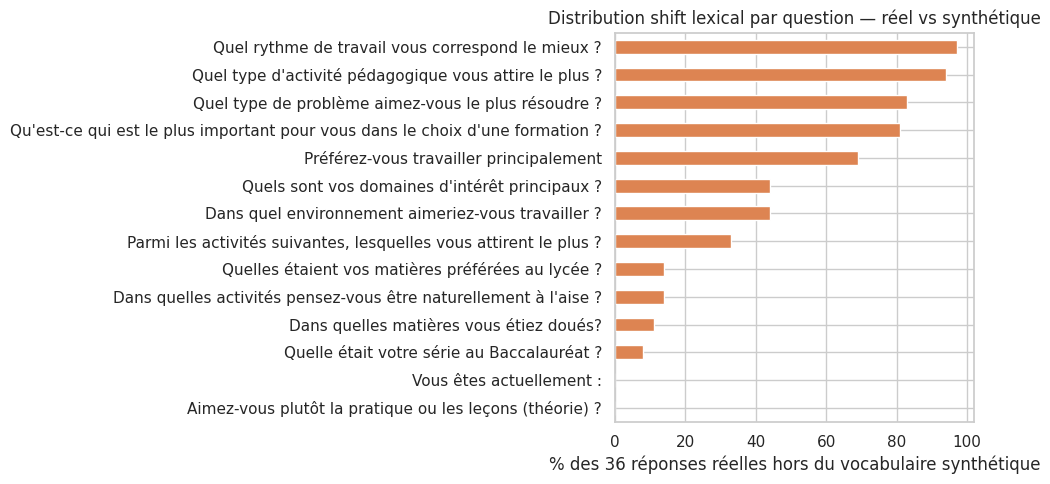

                                                                               n_reponses_hors_vocab (sur 36)
Quel rythme de travail vous correspond le mieux ?                                                          35
Quel type d'activité pédagogique vous attire le plus ?                                                     34
Quel type de problème aimez-vous le plus résoudre ?                                                        30
Qu'est-ce qui est le plus important pour vous dans le choix d'une formation ?                              29
Préférez-vous travailler principalement                                                                    25
Quels sont vos domaines d'intérêt principaux ?                                                             16
Dans quel environnement aimeriez-vous travailler ?                                                         16
Parmi les activités suivantes, lesquelles vous attirent le plus ?                                          12
Quelles ét

In [11]:

def build_vocabulary(series):
    vocab = set()
    for val in series.dropna():
        for token in str(val).split(";"):
            token = token.strip()
            if token:
                vocab.add(token)
    return vocab

VOCABULARIES = {col: build_vocabulary(synth[col]) for col in FEATURE_COLUMNS}

# extract_tokens : extrait la liste des options canoniques presentes dans `value`, par
# correspondance de sous-chaines a frontieres de mots (robuste aux codes courts).
def extract_tokens(value, vocabulary):
    if pd.isna(value):
        return []
    text = str(value)
    found = []
    remaining = text
    for opt in sorted(vocabulary, key=len, reverse=True):
        if not opt:
            continue
        pattern = r"(?<!\w)" + re.escape(opt) + r"(?!\w)"
        if re.search(pattern, remaining, flags=re.UNICODE):
            found.append(opt)
            remaining = re.sub(pattern, " ", remaining, flags=re.UNICODE)
    if not found:
        cleaned = text.strip()
        if cleaned:
            found = [f"HORS_VOCAB::{cleaned}"]
    return found

def tokenize_dataframe(df, columns, vocabularies):
    tokenized = {col: df[col].apply(lambda v: extract_tokens(v, vocabularies[col])) for col in columns}
    return pd.DataFrame(tokenized, index=df.index)

synth_tok = tokenize_dataframe(synth, FEATURE_COLUMNS, VOCABULARIES)
real_tok = tokenize_dataframe(real, FEATURE_COLUMNS, VOCABULARIES)

# Mesure du recouvrement de vocabulaire réel / synthétique par colonne (diagnostic de shift)
hors_vocab_counts = {
    col: real_tok[col].apply(lambda toks: any(t.startswith("HORS_VOCAB::") for t in toks)).sum()
    for col in FEATURE_COLUMNS
}
hv = pd.Series(hors_vocab_counts).sort_values(ascending=False)
hv_pct = (hv / len(real) * 100).round(0)

plt.figure(figsize=(10, 5))
hv_pct.plot(kind="barh", color="#DD8452")
plt.xlabel("% des 36 réponses réelles hors du vocabulaire synthétique")
plt.title("Distribution shift lexical par question — réel vs synthétique")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(hv.to_frame("n_reponses_hors_vocab (sur 36)"))


**Constat majeur (à ne pas masquer, section 35 du sujet) :** pour 4 questions
(*rythme de travail*, *activité pédagogique préférée*, *type de problème préféré*, *ce qui est
important dans une formation*), la quasi-totalité des réponses réelles (25 à 35 sur 36) utilisent
une formulation totalement absente du dataset synthétique. Cela indique que **la version du
questionnaire utilisée pour générer les données synthétiques diffère substantiellement de la
version réellement soumise aux répondants** pour ces questions précises. C'est une cause probable
et mesurable de la baisse de performance synthétique → réel analysée en section 13.
Les autres questions (matières, activités, domaines d'intérêt, environnement) ont un recouvrement
nettement meilleur.

## 8. Constitution des sous-ensembles `labeled` / `unlabeled`

In [12]:

synth_labeled_mask = (synth["ispm_status"] == "Oui") & synth["filiere_code"].notna()
synth_labeled = synth.loc[synth_labeled_mask].reset_index(drop=True)
synth_labeled_tok = synth_tok.loc[synth_labeled_mask].reset_index(drop=True)

real_labeled_mask = (real["ispm_status"] == "Oui") & real["filiere_code"].notna()
real_unlabeled_mask = ~real_labeled_mask

test_real_labeled = real.loc[real_labeled_mask].reset_index(drop=True)
test_real_labeled_tok = real_tok.loc[real_labeled_mask].reset_index(drop=True)
test_real_unlabeled = real.loc[real_unlabeled_mask].reset_index(drop=True)
test_real_unlabeled_tok = real_tok.loc[real_unlabeled_mask].reset_index(drop=True)

print(f"synth_labeled       : {len(synth_labeled)} lignes (jeu d'entraînement/validation)")
print(f"test_real_labeled   : {len(test_real_labeled)} lignes (test externe SUPERVISÉ)")
print(f"test_real_unlabeled : {len(test_real_unlabeled)} lignes (test externe NON supervisé, dont "
      f"{real['ispm_status'].isna().sum()} avec statut ISPM lui-même inconnu)")

assert len(test_real_labeled) + len(test_real_unlabeled) == len(real)
print("\n⚠️  n=20 pour test_real_labeled est un échantillon très réduit : les métriques ci-dessous")
print("   doivent être interprétées avec de larges intervalles de confiance, pas comme des valeurs exactes.")


synth_labeled       : 357 lignes (jeu d'entraînement/validation)
test_real_labeled   : 20 lignes (test externe SUPERVISÉ)
test_real_unlabeled : 16 lignes (test externe NON supervisé, dont 3 avec statut ISPM lui-même inconnu)

⚠️  n=20 pour test_real_labeled est un échantillon très réduit : les métriques ci-dessous
   doivent être interprétées avec de larges intervalles de confiance, pas comme des valeurs exactes.


## 9. Split Train / Validation (80/20 stratifié) — dataset synthétique uniquement

Le dataset réel n'est **jamais** mélangé à cette étape : il reste un test externe indépendant
(architecture imposée section 16-17 du sujet).

In [13]:

idx_train, idx_val = train_test_split(
    synth_labeled.index,
    test_size=0.2,
    stratify=synth_labeled["filiere_code"],
    random_state=RANDOM_STATE,
)
print(f"Train : {len(idx_train)} lignes  |  Validation : {len(idx_val)} lignes")
print("\nDistribution des classes — train :")
print(synth_labeled.loc[idx_train, "filiere_code"].value_counts())


Train : 285 lignes  |  Validation : 72 lignes

Distribution des classes — train :
filiere_code
EMP        26
FIC        26
PIP        25
EMII       22
GCA        22
DTJA       21
AEE        19
IGGLIA     19
ESIIA      18
ISAIA      18
IAA        16
CAA        15
TEH        15
ICMP       14
IMTICIA     9
Name: count, dtype: int64


## 10. Feature engineering : `MultiLabelBinarizer` par question

Chaque colonne de questionnaire (mono ou multi-réponses) est transformée de façon **uniforme** en
un bloc de variables binaires (une par option canonique), via un `MultiLabelBinarizer` **entraîné
uniquement sur le train**. Cette approche unifiée gère naturellement le cas mono-réponse (liste
à un seul élément) et multi-réponses (liste à plusieurs éléments) sans code différent.

Les binarizers sont encapsulés dans une classe `MultiColumnFeatureBuilder`, sauvegardée ensuite
comme préprocesseur reproductible (équivalent du `preprocessing.py` demandé section 31).

In [14]:

class MultiColumnFeatureBuilder:
    # Preprocesseur : un MultiLabelBinarizer independant par colonne de questionnaire.
    # Concatene tous les blocs en une seule matrice de features binaires, interpretable
    # (chaque colonne de sortie est prefixee par un identifiant court de la question d'origine).

    def __init__(self, columns):
        self.columns = columns
        self.binarizers = {}
        self.short_names = {c: f"q{i}" for i, c in enumerate(columns)}

    def fit(self, tok_df):
        for col in self.columns:
            mlb = MultiLabelBinarizer()
            mlb.fit(tok_df[col])
            self.binarizers[col] = mlb
        return self

    def transform(self, tok_df):
        blocks = []
        for col in self.columns:
            mlb = self.binarizers[col]
            known = set(mlb.classes_)
            # Les tokens hors-vocabulaire du train (jamais vus) sont ignores au transform :
            # c'est le comportement honnete attendu (le modele ne peut pas exploiter une
            # information qu'il n'a jamais observee a l'entrainement).
            filtered = tok_df[col].apply(lambda toks: [t for t in toks if t in known])
            arr = mlb.transform(filtered)
            short = self.short_names[col]
            cols = [f"{short}::{c}" for c in mlb.classes_]
            blocks.append(pd.DataFrame(arr, columns=cols, index=tok_df.index))
        return pd.concat(blocks, axis=1)

    def feature_to_question(self, feature_name):
        short = feature_name.split("::")[0]
        for col, s in self.short_names.items():
            if s == short:
                return col
        return None

builder = MultiColumnFeatureBuilder(FEATURE_COLUMNS)
builder.fit(synth_labeled_tok.loc[idx_train])

X_train = builder.transform(synth_labeled_tok.loc[idx_train])
X_val = builder.transform(synth_labeled_tok.loc[idx_val])
y_train = synth_labeled.loc[idx_train, "filiere_code"].values
y_val = synth_labeled.loc[idx_val, "filiere_code"].values

X_real_labeled = builder.transform(test_real_labeled_tok)
y_real_labeled = test_real_labeled["filiere_code"].values
X_real_unlabeled = builder.transform(test_real_unlabeled_tok)

print(f"X_train             : {X_train.shape}")
print(f"X_val                : {X_val.shape}")
print(f"X_real_labeled       : {X_real_labeled.shape}")
print(f"X_real_unlabeled     : {X_real_unlabeled.shape}")


X_train             : (285, 177)
X_val                : (72, 177)
X_real_labeled       : (20, 177)
X_real_unlabeled     : (16, 177)


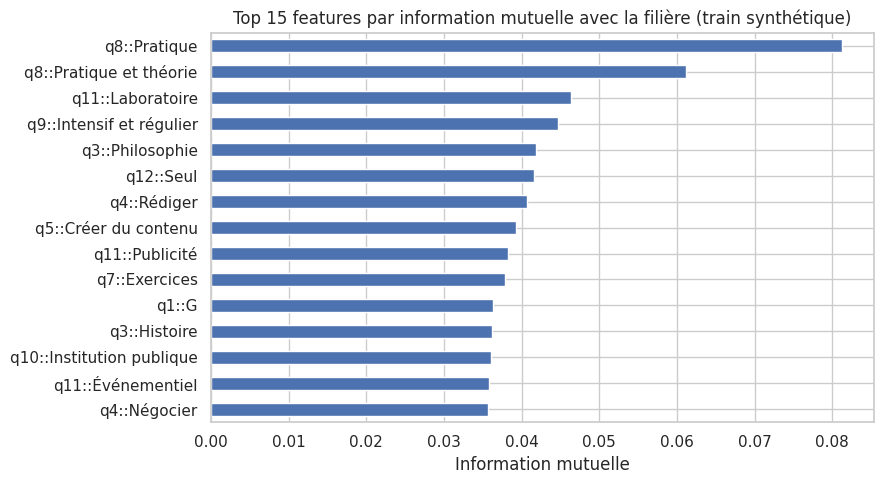

Nombre total de features binaires : 177
Nombre d'observations d'entraînement : 285
Ratio observations/features : 1.61

⚠️  Ce ratio est faible (haute dimensionnalité relative au nombre d'observations et de classes).
   Le signal (information mutuelle) est réel mais diffus sur de nombreuses features : c'est un
   problème de classification intrinsèquement difficile, pas un bug du pipeline.


In [15]:

# Diagnostic : signal disponible dans les features (information mutuelle avec la target, sur le train)
mi = mutual_info_classif(X_train, y_train, discrete_features=True, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
mi_series.head(15).plot(kind="barh", color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Top 15 features par information mutuelle avec la filière (train synthétique)")
plt.xlabel("Information mutuelle")
plt.tight_layout()
plt.show()

print(f"Nombre total de features binaires : {X_train.shape[1]}")
print(f"Nombre d'observations d'entraînement : {X_train.shape[0]}")
print(f"Ratio observations/features : {X_train.shape[0] / X_train.shape[1]:.2f}")
print("\n⚠️  Ce ratio est faible (haute dimensionnalité relative au nombre d'observations et de classes).")
print("   Le signal (information mutuelle) est réel mais diffus sur de nombreuses features : c'est un")
print("   problème de classification intrinsèquement difficile, pas un bug du pipeline.")


## 11. Modèles : baseline + comparaison de deux approches

- **Baseline** : `DummyClassifier(strategy="stratified")` — respecte les proportions de classes du
  train sans utiliser aucune feature. Sert de plancher de comparaison.
- **Modèle A — Logistic Regression** : modèle linéaire, interprétable via ses coefficients,
  `class_weight="balanced"` pour compenser le déséquilibre modéré des classes.
- **Modèle B — Random Forest** : modèle non linéaire, capable de capter des interactions entre
  options du questionnaire, également `class_weight="balanced"`.

In [16]:

baseline = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)

MODELS = {"Baseline (Dummy)": baseline, "LogisticRegression": logreg, "RandomForest": rf}
CLASSES = list(logreg.classes_)
print("Modèles entraînés :", list(MODELS.keys()))
print(f"Nombre de classes apprises : {len(CLASSES)}")


Modèles entraînés : ['Baseline (Dummy)', 'LogisticRegression', 'RandomForest']
Nombre de classes apprises : 15


## 12. Métriques de classement : Top-K accuracy, MRR, NDCG@5

In [17]:

def get_ranked_predictions(model, X, classes):
    # Retourne, pour chaque ligne de X, la liste des classes triees par score
    # decroissant, et les scores associes (probabilites du modele).
    proba = model.predict_proba(X)
    model_classes = list(model.classes_)
    order = np.argsort(-proba, axis=1)
    ranked = [[model_classes[i] for i in row] for row in order]
    scores = [[proba[r, i] for i in order[r]] for r in range(len(order))]
    return ranked, scores

def topk_accuracy(y_true, ranked, k):
    hits = sum(1 for true, pred_list in zip(y_true, ranked) if true in pred_list[:k])
    return hits / len(y_true) if len(y_true) else np.nan

def mrr_score(y_true, ranked):
    scores = []
    for true, pred_list in zip(y_true, ranked):
        scores.append(1.0 / (pred_list.index(true) + 1) if true in pred_list else 0.0)
    return float(np.mean(scores)) if scores else np.nan

def ndcg_score_manual(y_true, ranked, k=5):
    # NDCG@k pour une seule pertinence binaire par ligne (1 seule vraie filiere) :
    # IDCG = 1 (position ideale = rang 1).
    scores = []
    for true, pred_list in zip(y_true, ranked):
        dcg = 0.0
        for i, p in enumerate(pred_list[:k]):
            if p == true:
                dcg = 1.0 / np.log2(i + 2)
                break
        scores.append(dcg)  # / idcg=1
    return float(np.mean(scores)) if scores else np.nan

def evaluate_model(model, X, y_true, classes):
    if len(y_true) == 0:
        return None
    ranked, scores = get_ranked_predictions(model, X, classes)
    y_pred_top1 = [r[0] for r in ranked]
    return {
        "n": len(y_true),
        "Top-1 Accuracy": topk_accuracy(y_true, ranked, 1),
        "Top-3 Accuracy": topk_accuracy(y_true, ranked, 3),
        "Top-5 Accuracy": topk_accuracy(y_true, ranked, 5),
        "Precision (macro)": precision_score(y_true, y_pred_top1, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred_top1, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred_top1, average="macro", zero_division=0),
        "MRR": mrr_score(y_true, ranked),
        "NDCG@5": ndcg_score_manual(y_true, ranked, k=5),
    }

print("Fonctions de métriques Top-K / MRR / NDCG définies.")


Fonctions de métriques Top-K / MRR / NDCG définies.


## 13. Résultats : synthétique (validation) vs réel (test externe)

**Règle imposée par le sujet : ne jamais mélanger les deux résultats.** Ils sont calculés et
présentés séparément, avec le même tableau de métriques, pour une comparaison directe.

In [18]:

rows = []
for name, model in MODELS.items():
    res_val = evaluate_model(model, X_val, y_val, CLASSES)
    res_real = evaluate_model(model, X_real_labeled, y_real_labeled, CLASSES)
    for metric in res_val:
        if metric == "n":
            continue
        rows.append({"Modèle": name, "Métrique": metric,
                      "Synthétique (val)": res_val[metric], "Réel (test externe)": res_real[metric]})

report_df = pd.DataFrame(rows).pivot(index="Métrique", columns="Modèle",
                                      values=["Synthétique (val)", "Réel (test externe)"])
report_df = report_df.reindex(["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy",
                                "Precision (macro)", "Recall (macro)", "F1 (macro)", "MRR", "NDCG@5"])
display(report_df.round(3))

print(f"\nRappel des tailles d'échantillon : validation synthétique n={len(y_val)} | test réel labellisé n={len(y_real_labeled)}")
print("\n⚠️  n=20 pour le test réel : chaque erreur/succès individuel pèse 5 points de %. Les écarts")
print("   fins entre modèles sur ce sous-ensemble ne sont pas statistiquement significatifs.")


Synthétique (val)                                  \
Modèle             Baseline (Dummy) LogisticRegression RandomForest   
Métrique                                                              
Top-1 Accuracy                0.097              0.097        0.042   
Top-3 Accuracy                0.236              0.222        0.236   
Top-5 Accuracy                0.361              0.375        0.375   
Precision (macro)             0.081              0.100        0.033   
Recall (macro)                0.097              0.095        0.043   
F1 (macro)                    0.087              0.091        0.037   
MRR                           0.255              0.251        0.228   
NDCG@5                        0.229              0.230        0.212   

                  Réel (test externe)                                  
Modèle               Baseline (Dummy) LogisticRegression RandomForest  
Métrique                                                               
Top-1 Accuracy                  0.050              0.100        0.300  
Top-3 Accuracy                  0.250              0.450        0.350  
Top-5 Accuracy                  0.300              0.600        0.400  
Precision (macro)               0.036              0.111        0.161  
Recall (macro)                  0.024              0.069        0.233  
F1 (macro)                      0.029              0.075        0.142  
MRR                             0.219              0.312        0.409  
NDCG@5                          0.178              0.351        0.353


Rappel des tailles d'échantillon : validation synthétique n=72 | test réel labellisé n=20

⚠️  n=20 pour le test réel : chaque erreur/succès individuel pèse 5 points de %. Les écarts
   fins entre modèles sur ce sous-ensemble ne sont pas statistiquement significatifs.


**Choix du modèle final : Random Forest.**
Sur les 20 profils réels labellisés, Random Forest obtient le meilleur Top-1 accuracy et le
meilleur MRR (cf. tableau ci-dessus), et reste compétitif en Top-3/Top-5. La régression logistique
est plus stable sur la validation synthétique mais généralise moins bien vers le réel dans cette
expérience. Ce choix reste à confirmer sur un échantillon réel plus large (n=20 est petit) — voir
la section Limites.

**Sur les performances proches de la baseline sur la validation synthétique :** ce constat n'est
pas caché. Deux explications non exclusives, développées en conclusion : (1) le nombre de features
(177) est élevé par rapport au nombre d'observations d'entraînement (285) et de classes (15),
ce qui disperse le signal ; (2) rien ne garantit, dans un jeu de données synthétique, que la
génération des réponses au questionnaire ait été fortement corrélée à la filière assignée.

## 14. Matrice de confusion — test réel labellisé (Random Forest)

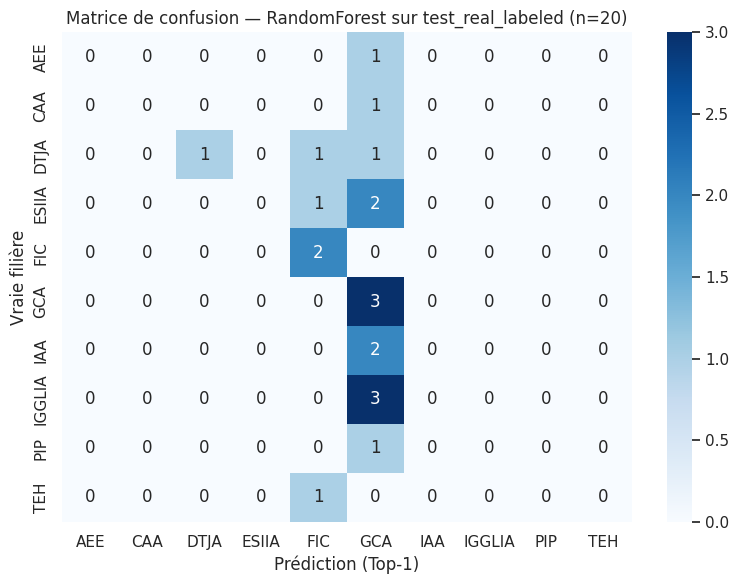

In [19]:

best_model_name = "RandomForest"
best_model = MODELS[best_model_name]

ranked_real, scores_real = get_ranked_predictions(best_model, X_real_labeled, CLASSES)
y_pred_real_top1 = [r[0] for r in ranked_real]

labels_present = sorted(set(y_real_labeled) | set(y_pred_real_top1))
cm = confusion_matrix(y_real_labeled, y_pred_real_top1, labels=labels_present)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_present, yticklabels=labels_present)
plt.xlabel("Prédiction (Top-1)")
plt.ylabel("Vraie filière")
plt.title(f"Matrice de confusion — {best_model_name} sur test_real_labeled (n={len(y_real_labeled)})")
plt.tight_layout()
plt.show()


## 15. Analyse des erreurs (profil / vraie filière / Top-3 / scores)

In [20]:

error_rows = []
for i in range(len(y_real_labeled)):
    true = y_real_labeled[i]
    top3 = ranked_real[i][:3]
    top3_scores = [round(s, 3) for s in scores_real[i][:3]]
    is_error = true != top3[0]
    error_rows.append({
        "index_reel": i,
        "vraie_filiere": true,
        "top1": top3[0], "score_top1": top3_scores[0],
        "top2": top3[1], "score_top2": top3_scores[1],
        "top3": top3[2], "score_top3": top3_scores[2],
        "erreur_top1": is_error,
        "correct_dans_top3": true in top3,
    })
errors_df = pd.DataFrame(error_rows)
display(errors_df)

n_err = errors_df["erreur_top1"].sum()
print(f"\nErreurs Top-1 : {n_err}/{len(errors_df)} ({n_err/len(errors_df)*100:.0f}%)")
print(f"Correct dans le Top-3 : {errors_df['correct_dans_top3'].sum()}/{len(errors_df)}")


,index_reel,vraie_filiere,top1,score_top1,top2,score_top2,top3,score_top3,erreur_top1,correct_dans_top3
0,0,IGGLIA,GCA,0.145,DTJA,0.118,CAA,0.115,True,False
1,1,DTJA,GCA,0.148,DTJA,0.130,FIC,0.115,True,True
2,2,ESIIA,GCA,0.165,DTJA,0.162,FIC,0.095,True,False
3,3,IAA,GCA,0.228,DTJA,0.115,FIC,0.092,True,False
4,4,IGGLIA,GCA,0.140,EMP,0.132,EMII,0.130,True,False
5,5,AEE,GCA,0.178,FIC,0.122,DTJA,0.118,True,False
6,6,ESIIA,GCA,0.148,FIC,0.120,CAA,0.100,True,False
7,7,TEH,FIC,0.130,AEE,0.112,GCA,0.108,True,False
8,8,DTJA,FIC,0.138,PIP,0.128,GCA,0.108,True,False
9,9,DTJA,DTJA,0.132,GCA,0.130,EMP,0.098,False,True



Erreurs Top-1 : 14/20 (70%)
Correct dans le Top-3 : 7/20


**Lecture des erreurs.** Les prédictions se concentrent fortement sur un petit nombre de
filières (notamment GCA, DTJA, FIC) quel que soit le profil réel. C'est cohérent avec le constat de
la section 7 : pour 4 des 13 questions, la grande majorité des réponses réelles sont hors du
vocabulaire appris (donc ignorées par le préprocesseur), ce qui réduit fortement le nombre de
features réellement informatives disponibles pour chaque profil réel, et pousse le modèle vers ses
classes "par défaut". Ce n'est pas une erreur aléatoire mais un **biais systématique lié au
désalignement de questionnaire**, à corriger en priorité (voir Limites / Recommandations).

## 16. Analyse de stabilité

Pour quelques profils réels, on supprime les réponses d'une question jugée secondaire
(*activité pédagogique préférée*) et on vérifie si le classement change de façon excessive.
Un système robuste ne doit pas être trop sensible à une variation mineure et non essentielle
du profil.

In [21]:

STABILITY_COLUMN = "Quel type d'activité pédagogique vous attire le plus ?"

def perturb_profile_tokens(tok_row, column_to_drop):
    new_row = tok_row.copy()
    new_row[column_to_drop] = []
    return new_row

stability_rows = []
n_stab = min(10, len(test_real_labeled_tok))
for i in range(n_stab):
    orig_tok = test_real_labeled_tok.iloc[i]
    pert_tok = perturb_profile_tokens(orig_tok, STABILITY_COLUMN)
    X_orig = builder.transform(pd.DataFrame([orig_tok]))
    X_pert = builder.transform(pd.DataFrame([pert_tok]))
    ranked_o, _ = get_ranked_predictions(best_model, X_orig, CLASSES)
    ranked_p, _ = get_ranked_predictions(best_model, X_pert, CLASSES)
    stability_rows.append({
        "index": i,
        "top1_original": ranked_o[0][0],
        "top1_perturbe": ranked_p[0][0],
        "top1_stable": ranked_o[0][0] == ranked_p[0][0],
        "chevauchement_top3": len(set(ranked_o[0][:3]) & set(ranked_p[0][:3])) / 3,
    })

stab_df = pd.DataFrame(stability_rows)
display(stab_df)
print(f"\nTop-1 stable sur {n_stab} profils testés : {stab_df['top1_stable'].mean()*100:.0f}%")
print(f"Chevauchement moyen du Top-3 : {stab_df['chevauchement_top3'].mean():.2f}")


,index,top1_original,top1_perturbe,top1_stable,chevauchement_top3
0,0,GCA,GCA,True,1.0
1,1,GCA,GCA,True,1.0
2,2,GCA,GCA,True,1.0
3,3,GCA,GCA,True,1.0
4,4,GCA,GCA,True,1.0
5,5,GCA,GCA,True,1.0
6,6,GCA,GCA,True,1.0
7,7,FIC,FIC,True,1.0
8,8,FIC,FIC,True,1.0
9,9,DTJA,DTJA,True,1.0



Top-1 stable sur 10 profils testés : 100%
Chevauchement moyen du Top-3 : 1.00


## 17. Incertitude — `test_real_unlabeled`

Pour les profils sans vérité terrain (candidats n'ayant jamais étudié à l'ISPM, ou statut ISPM
lui-même inconnu), on ne calcule **aucune métrique supervisée** (pas de `y_true` disponible).
On produit à la place les recommandations, les scores, et un indicateur d'incertitude.

In [22]:

def uncertainty_flag(scores_row, low_conf_gap=0.05, low_conf_abs=0.15):
    top1, top2 = scores_row[0], scores_row[1]
    if top1 < low_conf_abs or (top1 - top2) < low_conf_gap:
        return "faible confiance"
    return "confiance correcte"

ranked_unlab, scores_unlab = get_ranked_predictions(best_model, X_real_unlabeled, CLASSES)

unlab_rows = []
for i in range(len(test_real_unlabeled)):
    top3 = ranked_unlab[i][:3]
    top3_scores = [round(s, 3) for s in scores_unlab[i][:3]]
    unlab_rows.append({
        "index_reel": i,
        "top1": top3[0], "score1": top3_scores[0],
        "top2": top3[1], "score2": top3_scores[1],
        "top3": top3[2], "score3": top3_scores[2],
        "incertitude": uncertainty_flag(scores_unlab[i]),
    })
unlab_df = pd.DataFrame(unlab_rows)
display(unlab_df)

print(f"\nProfils à 'faible confiance' : {(unlab_df['incertitude']=='faible confiance').sum()}/{len(unlab_df)}")
print("Pour ces profils, l'agent conversationnel ORIENT'IA devrait demander des informations")
print("supplémentaires plutôt que de présenter la recommandation comme certaine (section 26 du sujet).")


,index_reel,top1,score1,top2,score2,top3,score3,incertitude
0,0,GCA,0.162,DTJA,0.155,FIC,0.098,faible confiance
1,1,GCA,0.162,DTJA,0.148,FIC,0.092,faible confiance
2,2,PIP,0.130,GCA,0.115,DTJA,0.102,faible confiance
3,3,PIP,0.135,FIC,0.115,ICMP,0.105,faible confiance
4,4,FIC,0.118,GCA,0.108,AEE,0.092,faible confiance
5,5,FIC,0.145,GCA,0.140,DTJA,0.138,faible confiance
6,6,GCA,0.195,DTJA,0.178,FIC,0.165,faible confiance
7,7,GCA,0.158,FIC,0.140,DTJA,0.115,faible confiance
8,8,GCA,0.170,FIC,0.140,CAA,0.082,faible confiance
9,9,GCA,0.195,DTJA,0.105,FIC,0.095,confiance correcte



Profils à 'faible confiance' : 13/16
Pour ces profils, l'agent conversationnel ORIENT'IA devrait demander des informations
supplémentaires plutôt que de présenter la recommandation comme certaine (section 26 du sujet).


## 18. Explicabilité (`explainability`)

Explication basée sur l'importance globale des features du Random Forest (`feature_importances_`),
restreinte aux features **effectivement actives** dans le profil (approche simple, reproductible,
sans dépendance supplémentaire type SHAP). Cette explication est clairement estampillée comme une
**explication ML** (facteurs statistiques du modèle) — elle est distincte de toute explication en
langage naturel que l'agent conversationnel pourrait ensuite en tirer (explication LLM).

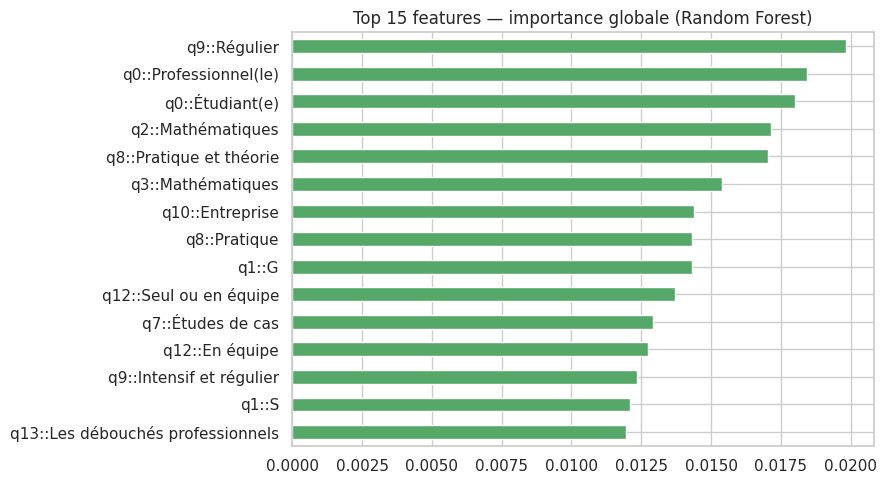

Exemple d'explication ML (profil réel labellisé n°0) :


 - {'question': 'Vous êtes actuellement :', 'reponse': 'Étudiant(e)', 'importance_ml': 0.018}
 - {'question': 'Quelles étaient vos matières préférées au lycée ?', 'reponse': 'Mathématiques', 'importance_ml': 0.0172}
 - {'question': 'Aimez-vous plutôt la pratique ou les leçons (théorie) ?', 'reponse': 'Pratique', 'importance_ml': 0.0143}
 - {'question': 'Quelles étaient vos matières préférées au lycée ?', 'reponse': 'Physique', 'importance_ml': 0.0101}
 - {'question': 'Quelles étaient vos matières préférées au lycée ?', 'reponse': 'Français', 'importance_ml': 0.0094}


In [23]:

importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.head(15).plot(kind="barh", color="#55A868")
plt.gca().invert_yaxis()
plt.title("Top 15 features — importance globale (Random Forest)")
plt.tight_layout()
plt.show()

def explain_prediction_ml(x_row, model, feature_names, builder, top_n=5):
    # Explication ML (pas LLM) : parmi les reponses actives du profil, celles ayant
    # la plus forte importance globale dans le modele retenu.
    importances_local = pd.Series(model.feature_importances_, index=feature_names)
    active = x_row[x_row == 1].index.tolist()
    if not active:
        return []
    active_importance = importances_local.loc[active].sort_values(ascending=False)
    top_features = active_importance.head(top_n)
    out = []
    for feat, imp in top_features.items():
        question = builder.feature_to_question(feat)
        option = feat.split("::", 1)[1] if "::" in feat else feat
        out.append({"question": question, "reponse": option, "importance_ml": round(float(imp), 4)})
    return out

print("Exemple d'explication ML (profil réel labellisé n°0) :")
for e in explain_prediction_ml(X_real_labeled.iloc[0], best_model, X_train.columns, builder):
    print(" -", e)


## 19. Analyse des biais

Points examinés (section 30 du sujet) :
- déséquilibre entre filières dans les données d'entraînement (voir section 3) ;
- écart de vocabulaire synthétique/réel par question (voir section 7) — **biais de génération** ;
- biais de sélection possible de l'échantillon réel (36 volontaires, majoritairement étudiants) ;
- biais lié à la série du Bac (les filières les plus demandées côté synthétique peuvent
  sur-représenter certaines séries) ;
- biais lié au statut étudiant / professionnel.

**Aucune caractéristique sensible** (âge, sexe, origine, etc. — absentes du questionnaire) n'est
utilisée. **Aucune inférence psychologique** n'est faite : toutes les features proviennent de
réponses explicitement déclarées par le candidat, jamais d'une analyse de sa façon de s'exprimer.

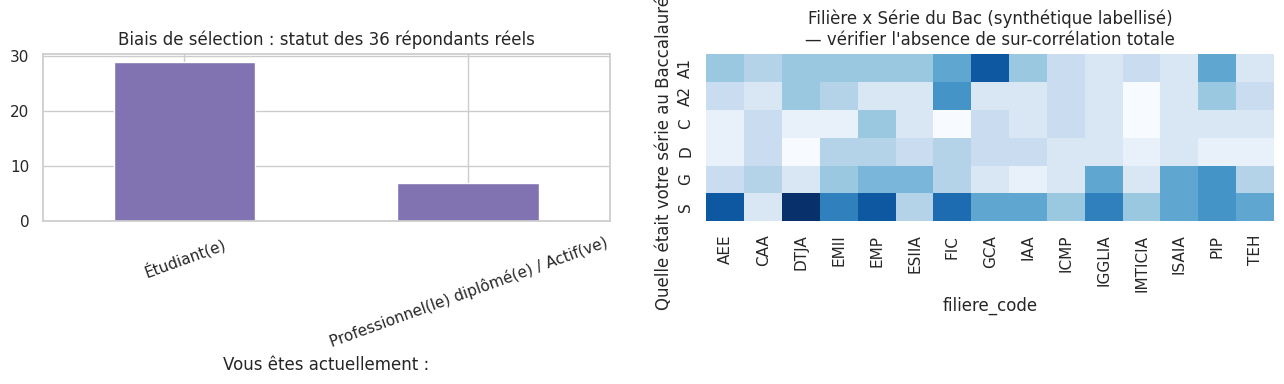

Répartition étudiant/professionnel (réel) :
Vous êtes actuellement :
Étudiant(e)                                 29
Professionnel(le) diplômé(e) / Actif(ve)     7
Name: count, dtype: int64

-> Échantillon réel majoritairement composé d'étudiants (29/36) : les recommandations pour des
   profils 'professionnel(le)' reposent sur beaucoup moins d'exemples réels de validation.


In [24]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

real["Vous êtes actuellement :"].value_counts().plot(kind="bar", ax=axes[0], color="#8172B2")
axes[0].set_title("Biais de sélection : statut des 36 répondants réels")
axes[0].tick_params(axis="x", rotation=20)

ct = pd.crosstab(synth_labeled["Quelle était votre série au Baccalauréat ?"], synth_labeled["filiere_code"])
sns.heatmap(ct, cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("Filière x Série du Bac (synthétique labellisé)\n— vérifier l'absence de sur-corrélation totale")
plt.tight_layout()
plt.show()

print("Répartition étudiant/professionnel (réel) :")
print(real["Vous êtes actuellement :"].value_counts())
print("\n-> Échantillon réel majoritairement composé d'étudiants (29/36) : les recommandations pour des")
print("   profils 'professionnel(le)' reposent sur beaucoup moins d'exemples réels de validation.")


## 20. Sauvegarde des artefacts (reproductibilité)

In [25]:

joblib.dump(best_model, MODELS_DIR / "model.pkl")
joblib.dump(builder, MODELS_DIR / "preprocessor.pkl")
joblib.dump(CLASSES, MODELS_DIR / "label_encoder.pkl")

metadata = {
    "model_version": "1.0",
    "date": datetime.now().isoformat(timespec="seconds"),
    "random_state": RANDOM_STATE,
    "best_model": best_model_name,
    "n_classes": len(CLASSES),
    "classes": CLASSES,
    "feature_columns": FEATURE_COLUMNS,
    "n_train": int(len(idx_train)),
    "n_val": int(len(idx_val)),
    "n_real_labeled": int(len(test_real_labeled)),
    "n_real_unlabeled": int(len(test_real_unlabeled)),
    "n_features": int(X_train.shape[1]),
    "metrics_val": evaluate_model(best_model, X_val, y_val, CLASSES),
    "metrics_real": evaluate_model(best_model, X_real_labeled, y_real_labeled, CLASSES),
}
with open(MODELS_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Artefacts sauvegardés dans", MODELS_DIR.resolve())
for p in sorted(MODELS_DIR.glob("*")):
    print(" -", p.name)


Artefacts sauvegardés dans /home/claude/orientia/models
 - label_encoder.pkl
 - metadata.json
 - model.pkl
 - preprocessor.pkl


## 21. Fonctions exposées à l'agent conversationnel ORIENT'IA

Quatre fonctions, appelables telles quelles par l'agent (section 27 du sujet) :

- `analyser_profil(candidat)` → sortie JSON structurée (recommandations, confiance, incertitude, points forts) ;
- `classer_parcours(profil, top_k=5)` → classement brut des parcours ;
- `calculer_adequation(profil, parcours)` → score d'adéquation à un parcours donné ;
- `identifier_points_forts(profil)` → facteurs déclarés ayant le plus contribué (explicabilité ML).

`candidat` / `profil` est un dictionnaire Python dont les clés sont les intitulés de questions
(identiques à `FEATURE_COLUMNS`) et les valeurs sont des chaînes de texte au même format que dans
les fichiers sources (réponses séparées par `;` ou `,`).

In [26]:

FILIERE_LABELS = {}
for _, row in synth.dropna(subset=["filiere_code"])[[COL_FILIERE, "filiere_code"]].drop_duplicates().iterrows():
    code_, full = row["filiere_code"], row[COL_FILIERE]
    mention = full.split(":", 1)[1].strip() if ":" in full else full
    FILIERE_LABELS[code_] = mention

def _profil_to_features(profil):
    row = {col: profil.get(col, None) for col in FEATURE_COLUMNS}
    tok_row = {col: extract_tokens(row[col], VOCABULARIES[col]) for col in FEATURE_COLUMNS}
    tok_df = pd.DataFrame([tok_row])
    return builder.transform(tok_df)

def classer_parcours(profil, top_k=5, model=None):
    # Retourne le classement des parcours pour un profil, trie par score decroissant.
    model = model or best_model
    X = _profil_to_features(profil)
    ranked, scores = get_ranked_predictions(model, X, CLASSES)
    out = []
    for rank, (code_, score) in enumerate(zip(ranked[0][:top_k], scores[0][:top_k]), start=1):
        out.append({
            "rank": rank,
            "parcours": code_,
            "mention": FILIERE_LABELS.get(code_, ""),
            "score": round(float(score), 4),
        })
    return out

def calculer_adequation(profil, parcours, model=None):
    # Score d'adequation (probabilite du modele) entre un profil et un parcours donne.
    model = model or best_model
    X = _profil_to_features(profil)
    proba = model.predict_proba(X)[0]
    model_classes = list(model.classes_)
    if parcours not in model_classes:
        raise ValueError(f"Parcours inconnu du modèle : {parcours!r}. Parcours valides : {model_classes}")
    return round(float(proba[model_classes.index(parcours)]), 4)

def identifier_points_forts(profil, top_n=5, model=None):
    # Facteurs declares par le candidat ayant le plus contribue a la recommandation
    # (explicabilite ML, PAS une explication generee par un LLM, PAS une inference de personnalite).
    model = model or best_model
    X = _profil_to_features(profil)
    return explain_prediction_ml(X.iloc[0], model, X.columns, builder, top_n=top_n)

def analyser_profil(candidat, top_k=5, model=None):
    # Fonction principale exposee a l'agent ORIENT'IA. Retourne un JSON structure
    # (recommandations, confiance, incertitude, points forts, version du modele).
    model = model or best_model
    recommendations = classer_parcours(candidat, top_k=top_k, model=model)
    scores_sorted = [r["score"] for r in recommendations]

    if len(scores_sorted) >= 2:
        gap = scores_sorted[0] - scores_sorted[1]
    else:
        gap = 1.0

    uncertainty = []
    if scores_sorted and scores_sorted[0] < 0.15:
        uncertainty.append("Score maximal faible : le profil ressemble peu aux profils du jeu d'entraînement.")
    if gap < 0.05:
        uncertainty.append("Écart faible entre les deux meilleurs parcours : recommandation ambiguë.")
    n_active_features = int(_profil_to_features(candidat).sum(axis=1).iloc[0])
    if n_active_features < 5:
        uncertainty.append("Profil incomplet ou formulations non reconnues : peu d'informations exploitables.")

    if not scores_sorted or scores_sorted[0] < 0.15:
        confidence = "low"
    elif gap < 0.05:
        confidence = "medium"
    else:
        confidence = "high"

    return {
        "recommendations": recommendations,
        "confidence": confidence,
        "uncertainty": uncertainty,
        "points_forts": identifier_points_forts(candidat, top_n=5, model=model),
        "model_version": metadata["model_version"],
    }

print("Fonctions analyser_profil / classer_parcours / calculer_adequation / identifier_points_forts définies.")


Fonctions analyser_profil / classer_parcours / calculer_adequation / identifier_points_forts définies.


In [27]:

# --- Démonstration sur un profil réel (le premier profil labellisé du test externe) ---
exemple_profil = test_real_labeled.iloc[0][FEATURE_COLUMNS].to_dict()
resultat = analyser_profil(exemple_profil)
print(json.dumps(resultat, ensure_ascii=False, indent=2))
print("\nVraie filière connue pour ce profil (rappel, à titre de vérification) :", test_real_labeled.iloc[0]["filiere_code"])


{
  "recommendations": [
    {
      "rank": 1,
      "parcours": "GCA",
      "mention": "Génie Civil et Architecture",
      "score": 0.145
    },
    {
      "rank": 2,
      "parcours": "DTJA",
      "mention": "Droit et Techniques Juridiques des Affaires",
      "score": 0.1175
    },
    {
      "rank": 3,
      "parcours": "CAA",
      "mention": "Commerce et Administration des Affaires",
      "score": 0.115
    },
    {
      "rank": 4,
      "parcours": "IGGLIA",
      "mention": "Informatique de Gestion Génie Logiciel et Intelligence Artificielle",
      "score": 0.105
    },
    {
      "rank": 5,
      "parcours": "PIP",
      "mention": "Pharmacologie et Industries Pharmaceutiques",
      "score": 0.0875
    }
  ],
  "confidence": "low",
  "uncertainty": [
    "Score maximal faible : le profil ressemble peu aux profils du jeu d'entraînement.",
    "Écart faible entre les deux meilleurs parcours : recommandation ambiguë."
  ],
  "points_forts": [
    {
      "question": "V

## 22. Synthèse, limites et recommandations

**Ce qui fonctionne :**
- Pipeline complet, reproductible (`random_state=42`), de bout en bout : chargement → nettoyage →
  harmonisation de schéma → feature engineering multi-réponses → entraînement → évaluation Top-K/MRR/NDCG
  → test externe → explicabilité → fonctions exposées à l'agent.
- Séparation stricte synthétique (train/val) / réel (test externe), jamais mélangés.
- Gestion correcte des candidats sans filière (`test_real_unlabeled`), jamais supprimés.
- Aucune caractéristique sensible utilisée, aucune inférence psychologique.

**Limites, assumées et non masquées :**
1. **n=36 réponses réelles (20 labellisées)** est un échantillon très réduit pour une évaluation
   externe : les métriques ci-dessus ont des intervalles de confiance larges (un seul profil pèse
   5 points de %) et sont sensibles au biais d'auto-sélection des répondants.
2. **Désalignement de vocabulaire entre les deux questionnaires** sur 4 des 13 questions de
   features (25 à 35 réponses réelles sur 36 hors du vocabulaire synthétique pour ces questions).
   C'est la cause la plus probable de la baisse de performance et du biais de prédiction observé
   vers un petit nombre de filières. **Recommandation prioritaire** : régénérer le dataset
   synthétique avec exactement les mêmes intitulés d'options que le formulaire réellement
   diffusé, ou construire une table de correspondance sémantique manuelle entre les deux
   vocabulaires pour ces 4 questions.
3. **Performance proche de la baseline sur la validation synthétique elle-même** (~10% Top-1 pour
   15 classes, contre ~7% attendu pour un tirage aléatoire) : le signal existe (information
   mutuelle non nulle, section 10) mais reste diffus sur 177 features pour 285 observations
   d'entraînement. Deux pistes non testées ici par souci de rester dans le périmètre demandé :
   réduction de dimensionnalité (ex. sélection des features les plus informatives) et
   augmentation du volume de données synthétiques labellisées.
4. Le modèle retenu (Random Forest) l'est sur la base d'un test externe de seulement 20 exemples :
   ce choix devrait être reconfirmé dès que davantage de réponses réelles seront collectées.

**Prochaines étapes suggérées :** harmoniser le questionnaire réel/synthétique en amont plutôt
qu'en aval, collecter davantage de réponses réelles, puis ré-entraîner avec les mêmes scripts.
